# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [42]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

/var/folders/l5/1dbkpbtn1md89c9k23nrcj9c0000gn/T/ipykernel_53859/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

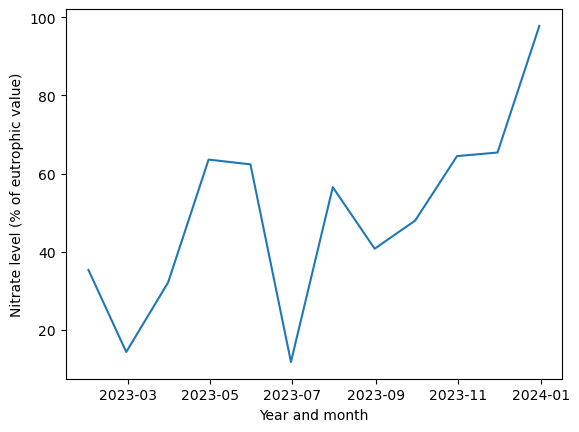

In [43]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/var/folders/l5/1dbkpbtn1md89c9k23nrcj9c0000gn/T/ipykernel_53859/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

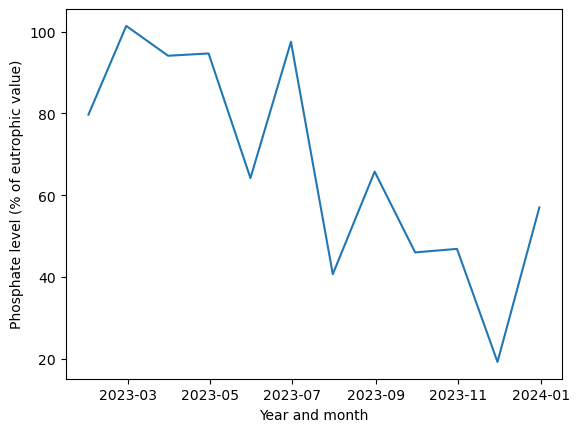

In [44]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

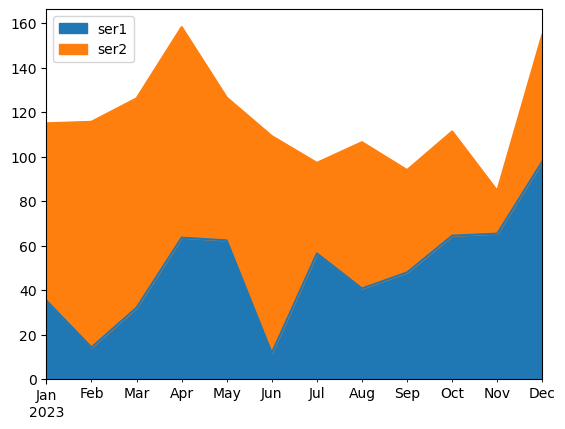

In [45]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

Upon looking at the graphs, I believe the strongest factor the area graph has on the line graphs is that everything is in one graph. Now if we say we can also combine the line graphs, sure, but the area graph really captures the attention with color difference and the area also captures how much visually we can see the nitrate vs phosphate levels in water. If i were to improve the line graphs, i would fit both of them at the same graph and color the lines differently and label the lines.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

The dataset is completely usable, no NA's, cleaned and ready to go. 

Annual revenue and days since last purchase are super right skewed, showing signs of possible relationship? Also conversion rate seems bimodal, meaning we can go for segmentation on this dataset. 

Correlation wise, the strongest relationships are days since last purchase and total purchase last year (negative)- marketing spend and annual revenue (positive). 

Upon further review for relationships:

The scatterplot shows a positive relationship between marketing spend and annual revenue. Companies that invest more in marketing tend to generate higher revenue, although there is substantial variability. This suggests that while marketing investment contributes to revenue growth, other factors such as conversion efficiency or customer base also influence outcomes.

Customers inactive for long periods are much less likely to generate revenue, which makes Days Since Last Purchase a strong candidate feature for churn prediction or customer engagement models.

In [46]:
import os
path = kagglehub.dataset_download( "ezogngrd/synthetic-b2b-crm-and-marketing-data")

print(path)
print(os.listdir(path))
import pandas as pd
import os

df_b2b = pd.read_csv(os.path.join(path, "companies_clean_734.csv"))
df_b2b.head()

/Users/riverocel/.cache/kagglehub/datasets/ezogngrd/synthetic-b2b-crm-and-marketing-data/versions/1
['employees_noisy_5234.csv', 'companies_clean_734.csv', 'companies_noisy_734.csv', 'employees_clean_5234.csv', 'employees_with_company_sample.csv']


,Company_ID,Industry,Company_Size,Annual_Revenue (M₺),Marketing_Spend (K₺),Campaign_Type,Leads_Generated,Conversion_Rate (%),Region,District,Last_Product_1,Last_Product_2,Frequency_of_Purchase,Days_Since_Last_Purchase,Contract_Status,Total_Purchases_Last_Year,Payment_Behavior,Preferred_Channel,Sales_Rep
0,C0001,"Mining, metals & minerals",Medium,17.3,33,SEM,12,0.9,Adana,Ceyhan,Process safety & automation,Valves,Monthly,6,Pending,15,On-time,Sales Rep,E**** T*******
1,C0002,Space,Small,4.9,12,Content Marketing,4,1.2,Sakarya,Arifiye,Energy storage systems,Actuators & motion control,Occasionally,310,Active,0,On-time,Sales Rep,D**** S*******
2,C0003,Buildings,Small,1.1,11,Content Marketing,9,1.1,Ankara,Etimesgut,Lighting & controls,Conduit & cable management,Quarterly,63,Active,4,Occasional delay,Sales Rep,B**** K*******
3,C0004,Oil & gas,Small,5.7,29,Trade Show,9,0.4,Eskisehir,Tepebasi,Medium-voltage power systems,Process safety & automation,Monthly,17,Active,8,On-time,Sales Rep,A**** Y*******
4,C0005,Oil & gas,Small,8.3,23,Trade Show,11,0.5,Zonguldak,Kozlu,Medium-voltage power systems,Fuel systems & emissions,Quarterly,93,Active,3,On-time,Sales Rep,C**** D*******


array([[<Axes: title={'center': 'Annual_Revenue (M₺)'}>,
        <Axes: title={'center': 'Marketing_Spend (K₺)'}>],
       [<Axes: title={'center': 'Leads_Generated'}>,
        <Axes: title={'center': 'Conversion_Rate (%)'}>],
       [<Axes: title={'center': 'Days_Since_Last_Purchase'}>,
        <Axes: title={'center': 'Total_Purchases_Last_Year'}>]],
      dtype=object)

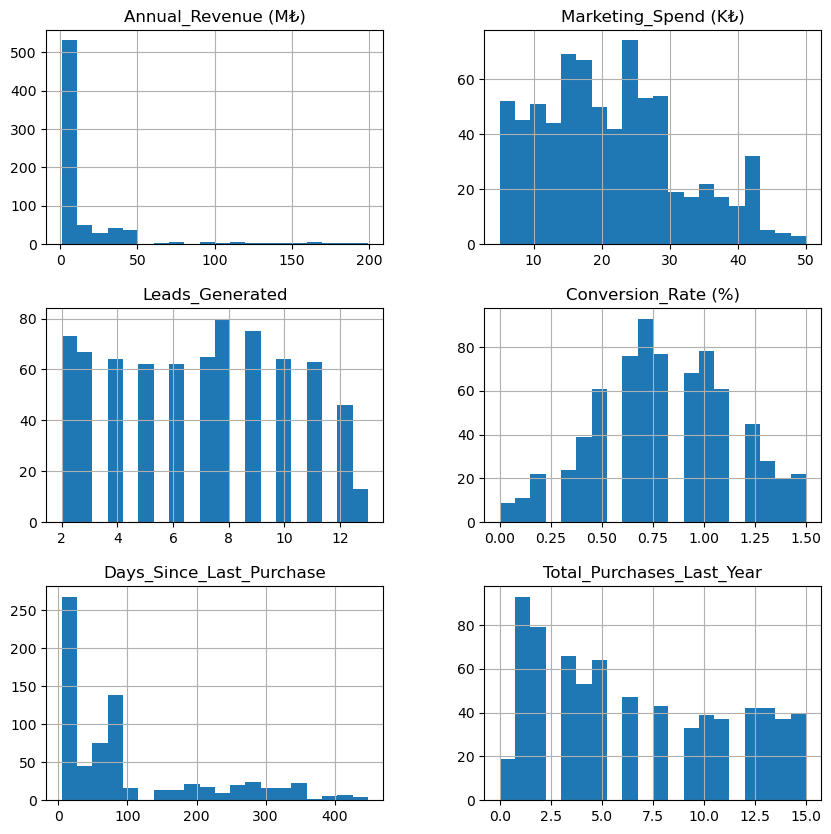

In [47]:
df_b2b.hist( bins = 20, figsize = (10, 10))

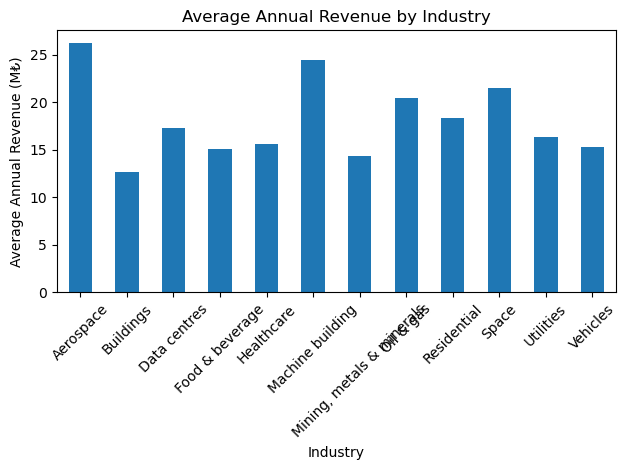

In [48]:
df_b2b.groupby("Industry")["Annual_Revenue (M₺)"].mean().plot(kind="bar")
plt.xlabel("Industry")
plt.ylabel("Average Annual Revenue (M₺)")
plt.title("Average Annual Revenue by Industry")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

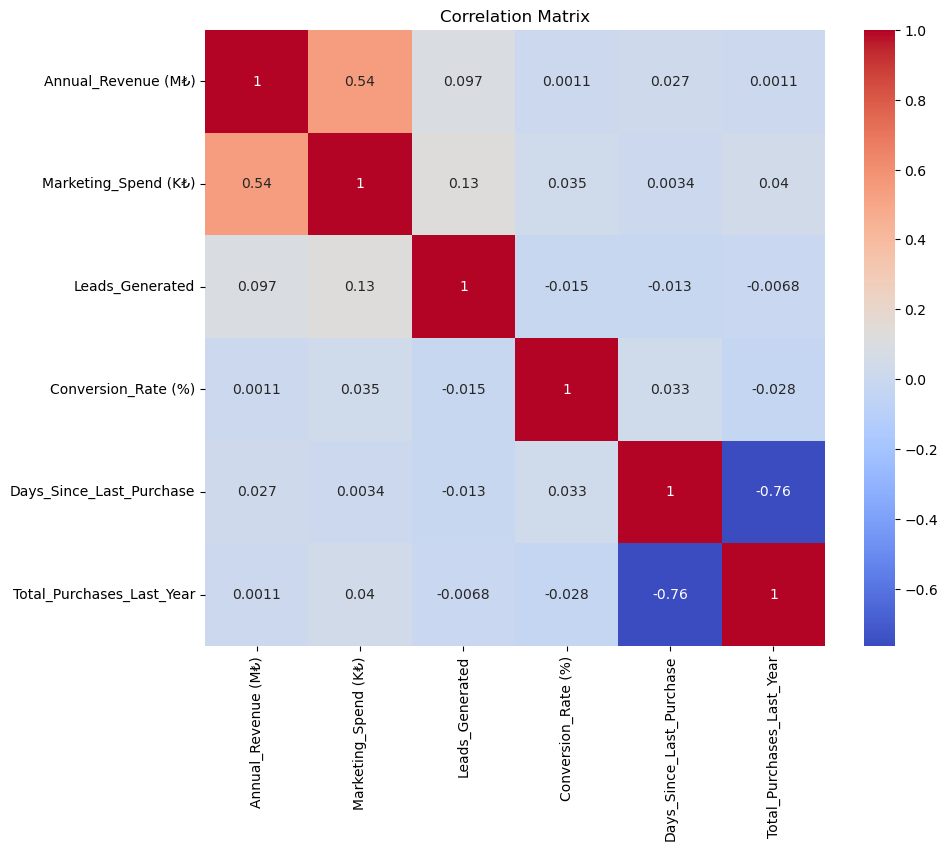

Annual_Revenue (M₺)          1.000000
Marketing_Spend (K₺)         0.540604
Leads_Generated              0.097167
Days_Since_Last_Purchase     0.026942
Total_Purchases_Last_Year    0.001094
Conversion_Rate (%)          0.001086
Name: Annual_Revenue (M₺), dtype: float64


In [49]:
num_col = df_b2b.select_dtypes(include='number').columns
cat_col = df_b2b.select_dtypes(exclude='number').columns 
corr = df_b2b[num_col].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
print(corr ["Annual_Revenue (M₺)"].sort_values(ascending=False))

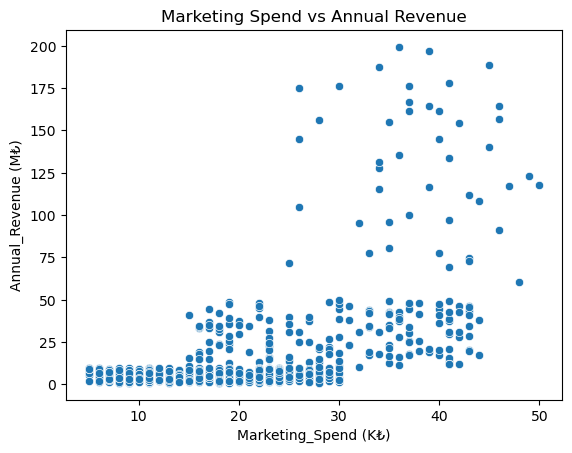

In [50]:
sns.scatterplot(data=df_b2b, x="Marketing_Spend (K₺)", y="Annual_Revenue (M₺)")
plt.title("Marketing Spend vs Annual Revenue")
plt.show()

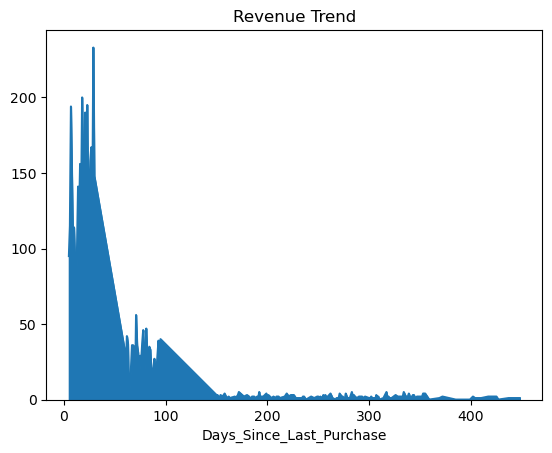

In [51]:
df_b2b.groupby("Days_Since_Last_Purchase")["Total_Purchases_Last_Year"].sum().plot.area()
plt.title("Revenue Trend")
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

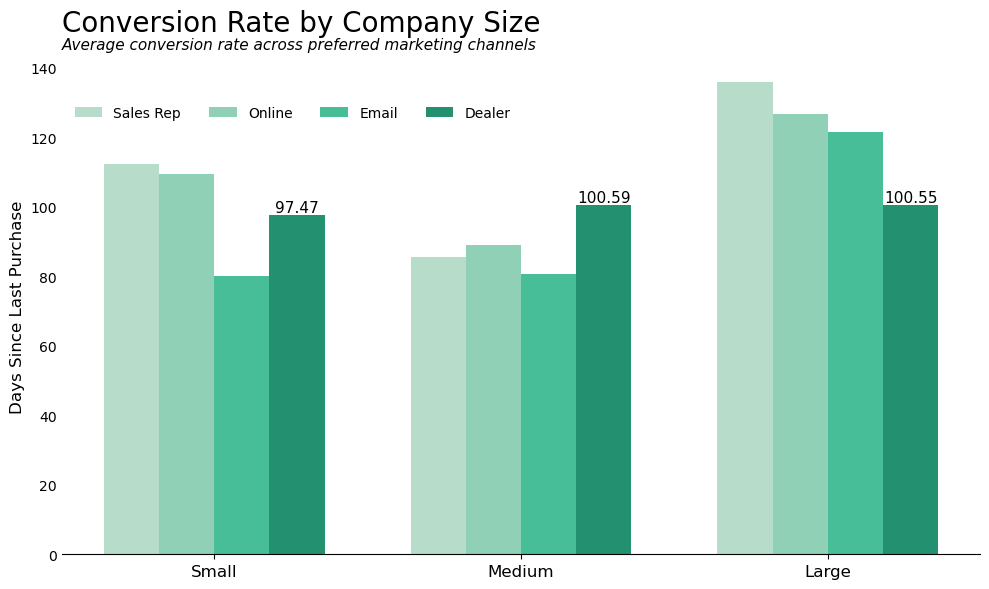

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Aggregate the data
plot_df = (
    df_b2b.groupby(["Company_Size", "Preferred_Channel"])["Days_Since_Last_Purchase"]
    .mean()
    .reset_index()
)

# Order categories manually if you want cleaner display
segment_order = ["Small", "Medium", "Large"]
channel_order = ["Sales Rep", "Online", "Email", "Dealer"]

plot_df["Company_Size"] = pd.Categorical(
    plot_df["Company_Size"], categories=segment_order, ordered=True
)
plot_df["Preferred_Channel"] = pd.Categorical(
    plot_df["Preferred_Channel"], categories=channel_order, ordered=True
)

plot_df = plot_df.sort_values(["Company_Size", "Preferred_Channel"])

# Pivot for grouped bar chart
pivot_df = plot_df.pivot(
    index="Company_Size",
    columns="Preferred_Channel",
    values="Days_Since_Last_Purchase"
)

# Colors similar to your example
colors = ["#b7dcca", "#8fd0b6", "#47be97", "#23916f"]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(pivot_df.index))
n_bars = len(pivot_df.columns)
bar_width = 0.18

for i, col in enumerate(pivot_df.columns):
    ax.bar(
        x + (i - (n_bars - 1) / 2) * bar_width,
        pivot_df[col],
        width=bar_width,
        label=col,
        color=colors[i]
    )

# Labels above the last bar in each group if wanted
for i in range(len(pivot_df.index)):
    last_val = pivot_df.iloc[i, -1]
    ax.text(
        x[i] + (n_bars - 1 - (n_bars - 1) / 2) * bar_width,
        last_val + 0.01,
        f"{last_val:.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Styling to mimic the screenshot
ax.set_title("Conversion Rate by Company Size", fontsize=20, loc="left", pad=20)
ax.text(
    0.0, 1.02,
    "Average conversion rate across preferred marketing channels",
    transform=ax.transAxes,
    fontsize=11,
    style="italic"
)

ax.set_xticks(x)
ax.set_xticklabels(pivot_df.index, fontsize=12)
ax.set_ylabel("Days Since Last Purchase", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(False)
ax.legend(title="", frameon=False, ncol=4, loc="upper left", bbox_to_anchor=(0, 0.93))

plt.tight_layout()
plt.show()